In [1]:
import sys
sys.path.append("..")

from src.data_loader import df

df.head()

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token
dataset already exists at ../data/ufo_sighting_data.csv


/Users/meryem/Documents/ufo_dataset_case_week4/Notebooks/../src/data_loader.py:34: DtypeWarning: Columns (0: length_of_encounter_seconds, 1: latitude) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path)


,Date_time,city,state/province,country,UFO_shape,length_of_encounter_seconds,described_duration_of_encounter,description,date_documented,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [4]:
%pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [kaggle]2m1/3 [jupytext]
Note: you may need to restart the kernel to use updated packages.


In [2]:
df.shape

(80332, 11)

In [3]:
df.columns

Index(['Date_time', 'city', 'state/province', 'country', 'UFO_shape',
       'length_of_encounter_seconds', 'described_duration_of_encounter',
       'description', 'date_documented', 'latitude', 'longitude'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date_time                        80332 non-null  str    
 1   city                             80332 non-null  str    
 2   state/province                   74535 non-null  str    
 3   country                          70662 non-null  str    
 4   UFO_shape                        78400 non-null  str    
 5   length_of_encounter_seconds      80332 non-null  object 
 6   described_duration_of_encounter  80332 non-null  str    
 7   description                      80317 non-null  str    
 8   date_documented                  80332 non-null  str    
 9   latitude                         80332 non-null  object 
 10  longitude                        80332 non-null  float64
dtypes: float64(1), object(2), str(8)
memory usage: 17.3+ MB


In [5]:
df.isnull().sum()

Date_time                             0
city                                  0
state/province                     5797
country                            9670
UFO_shape                          1932
length_of_encounter_seconds           0
described_duration_of_encounter       0
description                          15
date_documented                       0
latitude                              0
longitude                             0
dtype: int64

In [6]:
(df.isnull().sum() / len(df) * 100).round(2)

Date_time                           0.00
city                                0.00
state/province                      7.22
country                            12.04
UFO_shape                           2.41
length_of_encounter_seconds         0.00
described_duration_of_encounter     0.00
description                         0.02
date_documented                     0.00
latitude                            0.00
longitude                           0.00
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["length_of_encounter_seconds"].head(20)

0     2700
1     7200
2       20
3       20
4      900
5      300
6      180
7     1200
8      180
9      120
10     300
11     180
12    1800
13     180
14      30
15    1200
16     120
17    1800
18      20
19    2700
Name: length_of_encounter_seconds, dtype: object

In [3]:
import pandas as pd

pd.to_numeric(df["length_of_encounter_seconds"], errors="coerce").isna().sum()

NameError: name 'df' is not defined

In [11]:
numeric_duration = pd.to_numeric(
    df["length_of_encounter_seconds"],
    errors="coerce"
)

df[numeric_duration.isna()][
    ["length_of_encounter_seconds", "described_duration_of_encounter"]
]

,length_of_encounter_seconds,described_duration_of_encounter
27822,2`,each a few seconds
35692,8`,eight seconds
58591,0.5`,1/2 segundo


In [12]:
df["length_of_encounter_seconds"] = pd.to_numeric(
    df["length_of_encounter_seconds"].str.replace("`", "", regex=False),
    errors="coerce"
)

df["length_of_encounter_seconds"].dtype

dtype('float64')

In [13]:
df["length_of_encounter_seconds"].isna().sum()

np.int64(14796)

In [14]:
df["length_of_encounter_seconds"].isna().sum()

np.int64(14796)

In [16]:
df["length_of_encounter_seconds"] = pd.to_numeric(
    df["length_of_encounter_seconds"].astype(str).str.replace("`", "", regex=False),
    errors="coerce"
)

df["length_of_encounter_seconds"].isna().sum()

np.int64(14796)

In [17]:
test_duration = pd.to_numeric(
    df["length_of_encounter_seconds"].astype(str).str.replace("`", "", regex=False),
    errors="coerce"
)

df.loc[test_duration.isna(), "length_of_encounter_seconds"].head(30)

65536   NaN
65537   NaN
65538   NaN
65539   NaN
65540   NaN
65541   NaN
65542   NaN
65543   NaN
65544   NaN
65545   NaN
65546   NaN
65547   NaN
65548   NaN
65549   NaN
65550   NaN
65551   NaN
65552   NaN
65553   NaN
65554   NaN
65555   NaN
65556   NaN
65557   NaN
65558   NaN
65559   NaN
65560   NaN
65561   NaN
65562   NaN
65563   NaN
65564   NaN
65565   NaN
Name: length_of_encounter_seconds, dtype: float64

In [2]:
df["length_of_encounter_seconds"].isna().sum()

np.int64(0)

In [4]:
import pandas as pd

In [5]:
df["duration_seconds_clean"] = pd.to_numeric(
    df["length_of_encounter_seconds"]
      .astype(str)
      .str.replace("`", "", regex=False),
    errors="coerce"
)

df["duration_seconds_clean"].isna().sum()

np.int64(0)

In [6]:
pd.to_numeric(df["latitude"], errors="coerce").isna().sum()

np.int64(1)

In [7]:
latitude_numeric = pd.to_numeric(df["latitude"], errors="coerce")

df[latitude_numeric.isna()][
    ["latitude", "longitude", "city", "country"]
]

,latitude,longitude,city,country
43782,33q.200088,-105.624152,mescalero indian reservation,NaN


In [8]:
df["latitude_clean"] = pd.to_numeric(
    df["latitude"],
    errors="coerce"
)

df["latitude_clean"].isna().sum()

np.int64(1)

In [9]:
df["UFO_shape"].value_counts().head(10)

UFO_shape
light        16565
triangle      7865
circle        7608
fireball      6208
other         5649
unknown       5584
sphere        5387
disk          5213
oval          3733
formation     2457
Name: count, dtype: int64

In [10]:
df["datetime_clean"] = pd.to_datetime(
    df["Date_time"],
    errors="coerce"
)

df["datetime_clean"].isna().sum()

np.int64(694)

In [11]:
df.loc[df["datetime_clean"].isna(), "Date_time"].head(20)

388     10/11/2006 24:00
693      10/1/2001 24:00
962      10/1/2012 24:00
1067    10/12/2003 24:00
1221    10/12/2013 24:00
1222    10/12/2013 24:00
1317    10/13/2004 24:00
1359    10/13/2007 24:00
1445    10/13/2012 24:00
1663    10/14/2011 24:00
1709    10/15/1952 24:00
1754    10/15/1971 24:00
1797    10/15/1978 24:00
1809    10/15/1980 24:00
1824    10/15/1983 24:00
1949    10/15/1997 24:00
1997    10/15/1999 24:00
1998    10/15/1999 24:00
2065    10/15/2002 24:00
2146    10/15/2005 24:00
Name: Date_time, dtype: str

In [12]:
mask_24 = df["Date_time"].str.endswith("24:00")

dates_24 = pd.to_datetime(
    df.loc[mask_24, "Date_time"].str.replace("24:00", "00:00", regex=False),
    errors="coerce"
) + pd.Timedelta(days=1)

df.loc[mask_24, "datetime_clean"] = dates_24

df["datetime_clean"].isna().sum()

np.int64(0)

In [13]:
df["year"] = df["datetime_clean"].dt.year
df["month"] = df["datetime_clean"].dt.month
df["day_of_week"] = df["datetime_clean"].dt.day_name()
df["hour"] = df["datetime_clean"].dt.hour

df[["datetime_clean", "year", "month", "day_of_week", "hour"]].head()

,datetime_clean,year,month,day_of_week,hour
0,1949-10-10 20:30:00,1949,10,Monday,20
1,1949-10-10 21:00:00,1949,10,Monday,21
2,1955-10-10 17:00:00,1955,10,Monday,17
3,1956-10-10 21:00:00,1956,10,Wednesday,21
4,1960-10-10 20:00:00,1960,10,Monday,20


In [14]:
sightings_per_year = df["year"].value_counts().sort_index()

sightings_per_year.tail(20)

year
1995    1078
1996     834
1997    1255
1998    1767
1999    2805
2000    2772
2001    3122
2002    3235
2003    3962
2004    4257
2005    4083
2006    3721
2007    4269
2008    4819
2009    4542
2010    4283
2011    5107
2012    7356
2013    7038
2014    2260
Name: count, dtype: int64

In [15]:
df["datetime_clean"].min(), df["datetime_clean"].max()

(Timestamp('1906-11-11 00:00:00'), Timestamp('2014-05-08 18:45:00'))

In [16]:
df.nsmallest(10, "datetime_clean")[
    ["Date_time", "datetime_clean", "city", "country", "description"]
]

,Date_time,datetime_clean,city,country,description
7863,11/11/1906 00:00,1906-11-11 00:00:00,wien (austria),NaN,The oldest professional photo of a UFO object ...
10580,1/1/1910 24:00,1910-01-02 00:00:00,kirksville (near),us,Historical sighting (1903 - 1913) Northern Mis...
46858,6/1/1910 15:00,1910-06-01 15:00:00,wills point,us,Cigar shaped object moving from West to East
40275,4/5/1916 13:00,1916-04-05 13:00:00,france (above; from aircraft),NaN,((NUFORC Note: Possible hoax. PD)) Saw 3 ci...
46694,6/11/1920 21:00,1920-06-11 21:00:00,cicero,us,((NUFORC Note: Probable hoax. Note date. PD...
20951,12/28/1925 18:00,1925-12-28 18:00:00,atkinson (6 miles north of),us,Young boy witnesses disc in sky above Illinois...
62760,7/5/1929 14:00,1929-07-05 14:00:00,buchanan (or burns),us,we were traveling east of burns&#44clmbing up ...
46859,6/1/1930 22:00,1930-06-01 22:00:00,ithaca/freeville,NaN,Very Large Triangle Shapped Object
26550,2/15/1931 14:00,1931-02-15 14:00:00,holyoke (6-8 miles southwest of),us,In the winter of 1931&#44 I saw a flying machi...
46860,6/1/1931 13:00,1931-06-01 13:00:00,abilene,us,This is a what my mother related to me regardi...


In [17]:
df["hour"].value_counts().sort_index()

hour
0      4802
1      3210
2      2357
3      2004
4      1529
5      1591
6      1224
7       905
8       803
9       958
10     1166
11     1144
12     1368
13     1303
14     1322
15     1433
16     1620
17     2592
18     4002
19     6147
20     8617
21    11445
22    10837
23     7953
Name: count, dtype: int64

In [18]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["day_of_week"].value_counts().reindex(day_order)

day_of_week
Monday       10094
Tuesday      10777
Wednesday    10964
Thursday     11024
Friday       11620
Saturday     14062
Sunday       11791
Name: count, dtype: int64

In [20]:
import pandas as pd

In [22]:
population_df = pd.read_csv(
    "../data/US-population-by-state(wide)-selected-columns.csv"
)

population_df.head()

,year,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,District of Columbia
0,1790,NaN,NaN,NaN,NaN,NaN,NaN,237946,59096,NaN
1,1800,NaN,NaN,NaN,NaN,NaN,NaN,251002,64273,8144.0
2,1810,NaN,NaN,NaN,1062.0,NaN,NaN,262042,72674,15471.0
3,1820,NaN,NaN,NaN,14273.0,NaN,NaN,275202,72749,23336.0
4,1830,NaN,NaN,NaN,30388.0,NaN,NaN,297675,76748,30261.0


In [23]:
population_df.shape

(136, 10)

In [24]:
population_df.columns

Index(['year', 'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia'],
      dtype='str')

In [25]:
df["state/province"].value_counts().head(20)

state/province
ca    9655
wa    4268
fl    4200
tx    3677
ny    3219
az    2689
il    2645
pa    2582
oh    2425
mi    2071
nc    1869
or    1845
on    1584
mo    1576
nj    1512
co    1505
va    1393
in    1386
ma    1358
ga    1347
Name: count, dtype: int64

In [26]:
states_to_check = ["al", "ak", "az", "ar", "ca", "co", "ct", "de", "dc"]

df[df["state/province"].isin(states_to_check)]["state/province"].value_counts()

state/province
ca    9655
az    2689
co    1505
ct     968
al     691
ar     666
ak     354
de     183
dc      99
Name: count, dtype: int64

In [27]:
population_df["year"].min(), population_df["year"].max()

(np.int64(1790), np.int64(2024))

In [28]:
population_long = population_df.melt(
    id_vars="year",
    var_name="state",
    value_name="population"
)

population_long.head(10)

,year,state,population
0,1790,Alabama,NaN
1,1800,Alabama,NaN
2,1810,Alabama,NaN
3,1820,Alabama,NaN
4,1830,Alabama,NaN
5,1840,Alabama,NaN
6,1850,Alabama,NaN
7,1860,Alabama,NaN
8,1870,Alabama,NaN
9,1880,Alabama,NaN


In [29]:
population_long[
    population_long["year"].between(1906, 2014)
]["population"].isna().sum()

np.int64(109)

In [30]:
population_long[
    population_long["population"].notna()
]["year"].unique()

array([1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910,
       1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921,
       1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932,
       1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943,
       1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954,
       1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965,
       1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976,
       1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 1880, 1890, 1870, 1810, 1820, 1830, 1840,
       1850, 1860, 1790, 1800])

In [31]:
population_long[
    population_long["year"].between(1906, 2014)
].groupby("state")["population"].apply(lambda x: x.isna().sum())

state
Alabama                   0
Alaska                  109
Arizona                   0
Arkansas                  0
California                0
Colorado                  0
Connecticut               0
Delaware                  0
District of Columbia      0
Name: population, dtype: int64

In [32]:
population_long[
    (population_long["state"] == "Alaska") &
    (population_long["population"].notna())
][["year", "population"]].head(10)

,year,population
145,1880,33426.0
146,1890,32052.0


In [33]:
population_long[
    population_long["year"] == 2014
][["state", "population"]]

,state,population
125,Alabama,4843737.0
261,Alaska,NaN
397,Arizona,6732873.0
533,Arkansas,2968759.0
669,California,38586706.0
805,Colorado,5352637.0
941,Connecticut,3595697.0
1077,Delaware,933131.0
1213,District of Columbia,663603.0


In [34]:
state_mapping = {
    "al": "Alabama",
    "ak": "Alaska",
    "az": "Arizona",
    "ar": "Arkansas",
    "ca": "California",
    "co": "Colorado",
    "ct": "Connecticut",
    "de": "Delaware",
    "dc": "District of Columbia"
}

In [35]:
df["state"] = df["state/province"].map(state_mapping)

df[["state/province", "state"]].dropna().head(10)

,state/province,state
7,ct,Connecticut
8,al,Alabama
10,ca,California
17,ct,Connecticut
30,ca,California
31,co,Colorado
43,co,Colorado
45,ca,California
60,ar,Arkansas
63,ca,California


In [36]:
df["state"].notna().sum()

np.int64(16810)

In [37]:
ufo_per_state_year = (
    df[df["state"].notna()]
    .groupby(["year", "state"])
    .size()
    .reset_index(name="ufo_count")
)

ufo_per_state_year.head(10)

,year,state,ufo_count
0,1931,Colorado,1
1,1936,Alaska,1
2,1937,California,1
3,1939,Alabama,1
4,1943,Alaska,1
5,1944,California,1
6,1945,California,2
7,1946,Arizona,1
8,1946,California,2
9,1947,California,6


In [38]:
ufo_per_state_year.shape, population_long.shape

((457, 3), (1224, 3))

In [39]:
merged_df = ufo_per_state_year.merge(
    population_long,
    on=["year", "state"],
    how="left"
)

merged_df.shape

(457, 4)

In [40]:
merged_df[merged_df["population"].isna()][
    ["year", "state", "ufo_count", "population"]
]

,year,state,ufo_count,population
1,1936,Alaska,1,NaN
4,1943,Alaska,1,NaN
12,1949,Alaska,2,NaN
27,1954,Alaska,1,NaN
38,1957,Alaska,2,NaN
55,1962,Alaska,1,NaN
77,1966,Alaska,1,NaN
91,1968,Alaska,2,NaN
99,1969,Alaska,4,NaN
119,1972,Alaska,1,NaN


In [41]:
analysis_df = merged_df.dropna(subset=["population"]).copy()

analysis_df.shape

(408, 4)

In [42]:
analysis_df["ufo_per_100k"] = (
    analysis_df["ufo_count"] / analysis_df["population"]
) * 100000

analysis_df.head(10)

,year,state,ufo_count,population,ufo_per_100k
0,1931,Colorado,1,1056000.0,0.094697
2,1937,California,1,6528000.0,0.015319
3,1939,Alabama,1,2814000.0,0.035537
5,1944,California,1,8945000.0,0.011179
6,1945,California,2,9344000.0,0.021404
7,1946,Arizona,1,616000.0,0.162338
8,1946,California,2,9559000.0,0.020923
9,1947,California,6,9832000.0,0.061025
10,1948,California,1,10064000.0,0.009936
11,1949,Alabama,2,3000000.0,0.066667


In [43]:
analysis_df[
    analysis_df["year"] == 2013
].sort_values("ufo_per_100k", ascending=False)

,year,state,ufo_count,population,ufo_per_100k
445,2013,Connecticut,123,3595792.0,3.420665
441,2013,Arizona,215,6634690.0,3.240543
444,2013,Colorado,132,5270774.0,2.504376
443,2013,California,670,38253768.0,1.751461
442,2013,Arkansas,50,2960459.0,1.688927
439,2013,Alabama,71,4831586.0,1.469497
446,2013,Delaware,12,924062.0,1.298614
447,2013,District of Columbia,2,651559.0,0.306956


In [44]:
analysis_df["ufo_per_100k"].describe()

count    408.000000
mean       0.536365
std        0.725537
min        0.009674
25%        0.085560
50%        0.160750
75%        0.848595
max        4.060958
Name: ufo_per_100k, dtype: float64

In [45]:
analysis_df.loc[analysis_df["ufo_per_100k"].idxmax()]

year                   2012
state           Connecticut
ufo_count               146
population        3595211.0
ufo_per_100k       4.060958
Name: 436, dtype: object

In [46]:
yearly_sightings = (
    df[df["year"].between(1949, 2013)]
    .groupby("year")
    .size()
    .reset_index(name="ufo_count")
)

yearly_sightings.head()

,year,ufo_count
0,1949,16
1,1950,28
2,1951,20
3,1952,49
4,1953,33


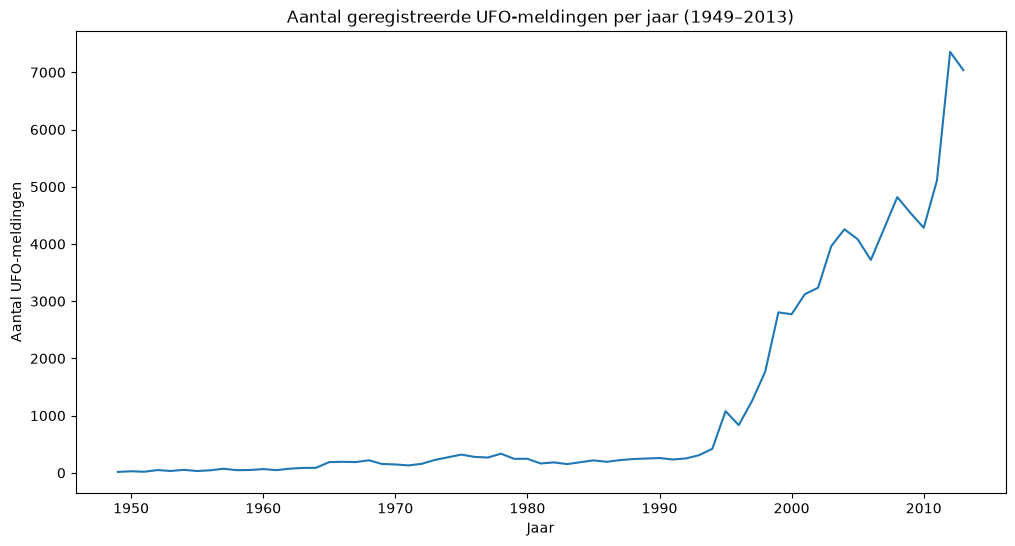

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_sightings["year"],
    yearly_sightings["ufo_count"]
)

plt.xlabel("Jaar")
plt.ylabel("Aantal UFO-meldingen")
plt.title("Aantal geregistreerde UFO-meldingen per jaar (1949–2013)")

plt.show()

In [48]:
state_2013 = (
    analysis_df[analysis_df["year"] == 2013]
    .sort_values("ufo_per_100k", ascending=False)
)

state_2013

,year,state,ufo_count,population,ufo_per_100k
445,2013,Connecticut,123,3595792.0,3.420665
441,2013,Arizona,215,6634690.0,3.240543
444,2013,Colorado,132,5270774.0,2.504376
443,2013,California,670,38253768.0,1.751461
442,2013,Arkansas,50,2960459.0,1.688927
439,2013,Alabama,71,4831586.0,1.469497
446,2013,Delaware,12,924062.0,1.298614
447,2013,District of Columbia,2,651559.0,0.306956


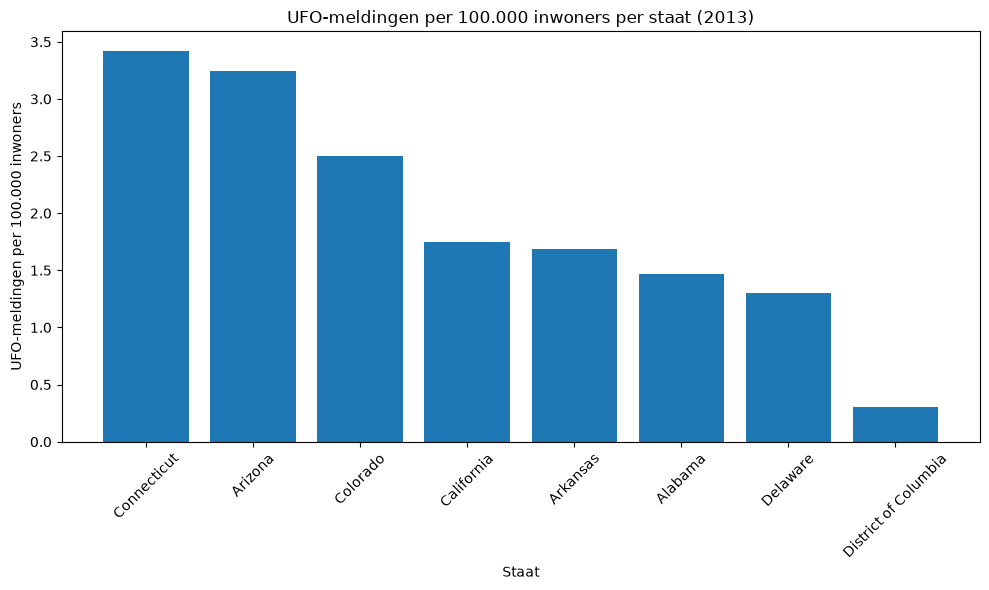

In [49]:
plt.figure(figsize=(10, 6))

plt.bar(
    state_2013["state"],
    state_2013["ufo_per_100k"]
)

plt.xlabel("Staat")
plt.ylabel("UFO-meldingen per 100.000 inwoners")
plt.title("UFO-meldingen per 100.000 inwoners per staat (2013)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [50]:
hourly_sightings = (
    df["hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hourly_sightings.columns = ["hour", "ufo_count"]

hourly_sightings

,hour,ufo_count
0,0,4802
1,1,3210
2,2,2357
3,3,2004
4,4,1529
5,5,1591
6,6,1224
7,7,905
8,8,803
9,9,958


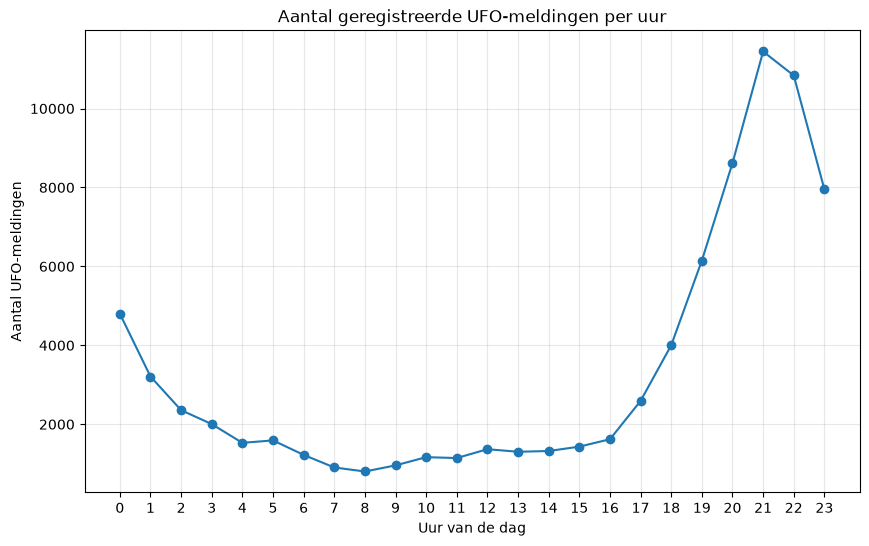

In [51]:
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_sightings["hour"],
    hourly_sightings["ufo_count"],
    marker="o"
)

plt.xlabel("Uur van de dag")
plt.ylabel("Aantal UFO-meldingen")
plt.title("Aantal geregistreerde UFO-meldingen per uur")

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.show()

In [52]:
shape_counts = (
    df["UFO_shape"]
    .value_counts()
    .head(10)
    .reset_index()
)

shape_counts.columns = ["UFO_shape", "ufo_count"]

shape_counts

,UFO_shape,ufo_count
0,light,16565
1,triangle,7865
2,circle,7608
3,fireball,6208
4,other,5649
5,unknown,5584
6,sphere,5387
7,disk,5213
8,oval,3733
9,formation,2457


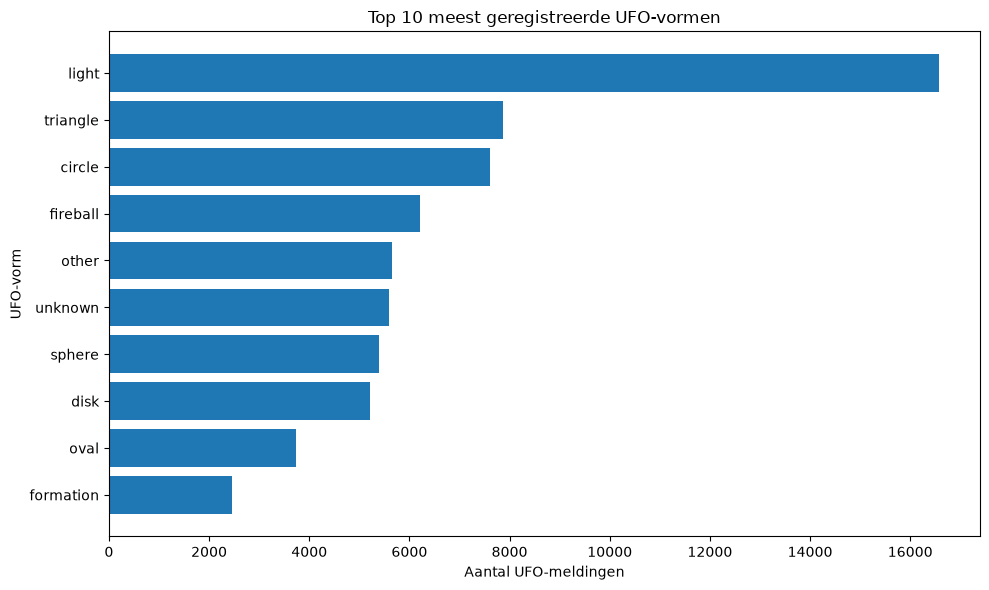

In [53]:
plt.figure(figsize=(10, 6))

plt.barh(
    shape_counts["UFO_shape"],
    shape_counts["ufo_count"]
)

plt.xlabel("Aantal UFO-meldingen")
plt.ylabel("UFO-vorm")
plt.title("Top 10 meest geregistreerde UFO-vormen")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [54]:
df.columns

Index(['Date_time', 'city', 'state/province', 'country', 'UFO_shape',
       'length_of_encounter_seconds', 'described_duration_of_encounter',
       'description', 'date_documented', 'latitude', 'longitude',
       'duration_seconds_clean', 'latitude_clean', 'datetime_clean', 'year',
       'month', 'day_of_week', 'hour', 'state'],
      dtype='str')

In [55]:
analysis_df.info()

<class 'pandas.DataFrame'>
Index: 408 entries, 0 to 456
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          408 non-null    int32  
 1   state         408 non-null    str    
 2   ufo_count     408 non-null    int64  
 3   population    408 non-null    float64
 4   ufo_per_100k  408 non-null    float64
dtypes: float64(2), int32(1), int64(1), str(1)
memory usage: 37.4 KB


In [56]:
analysis_df = analysis_df.reset_index(drop=True)

analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          408 non-null    int32  
 1   state         408 non-null    str    
 2   ufo_count     408 non-null    int64  
 3   population    408 non-null    float64
 4   ufo_per_100k  408 non-null    float64
dtypes: float64(2), int32(1), int64(1), str(1)
memory usage: 18.2 KB


In [57]:
population_long[
    population_long["state"] != "Alaska"
].groupby("year")["population"].count().tail(30)

year
1995    8
1996    8
1997    8
1998    8
1999    8
2000    8
2001    8
2002    8
2003    8
2004    8
2005    8
2006    8
2007    8
2008    8
2009    8
2010    8
2011    8
2012    8
2013    8
2014    8
2015    8
2016    8
2017    8
2018    8
2019    8
2020    8
2021    8
2022    8
2023    8
2024    8
Name: population, dtype: int64

In [58]:
population_analysis = population_long[
    (population_long["state"] != "Alaska") &
    (population_long["year"].between(1949, 2013))
].copy()

population_analysis.shape

(520, 3)

In [59]:
dashboard_df = population_analysis.merge(
    ufo_per_state_year,
    on=["year", "state"],
    how="left"
)

dashboard_df["ufo_count"] = dashboard_df["ufo_count"].fillna(0).astype(int)

dashboard_df.shape

(520, 4)

In [60]:
dashboard_df["ufo_per_100k"] = (
    dashboard_df["ufo_count"] / dashboard_df["population"]
) * 100000

dashboard_df.head()

,year,state,population,ufo_count,ufo_per_100k
0,1949,Alabama,3000000.0,2,0.066667
1,1950,Alabama,3058000.0,0,0.000000
2,1951,Alabama,3059000.0,1,0.032690
3,1952,Alabama,3068000.0,0,0.000000
4,1953,Alabama,3053000.0,0,0.000000


In [61]:
import streamlit as st

st.__version__

'1.58.0'

In [6]:
pdf = pd.read_csv("ufo_sighting_data.csv")
print(pdf.head())

FileNotFoundError: [Errno 2] No such file or directory: 'ufo_sighting_data.csv'